<a href="https://colab.research.google.com/github/rituraj735/HeadCue/blob/main/Ritu's_Copy_of_DataSetTest(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

section_dict = {}

for i in range (1, 25):
  section_dict[i] = list()

# gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu", "mouth-stretch-imu"] # need to explore other gestures based on their graphs
gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu"] # need to explore other gestures based on their graphs

def scale_columns(df): # here we scale the columns of the accelerometer data by multiplying it by a factor of 0.061
  for col in df.columns:
    if col.startswith('a'):
      df[col] = df[col] * 0.061
  return df

root_location = "/content/drive/MyDrive/Wireless project/P"
for i in range(1,25):
  if (i == 2):
    continue
  for files in os.listdir(root_location + str(i)):
    if (files[2:len(files)-9] not in gestures and files[3: len(files)-9] not in gestures):
      continue
    if files.endswith("right.csv"):
      continue
    df = pd.read_csv(os.path.join(root_location + str(i), files))
    #apply scaling here for simplicity
    df = df.pipe(scale_columns)
    df_sorted = df.sort_values(by='timestamp')
    df = df_sorted.reset_index(drop=True) # when sorting of data frame happens in previous lines based on the timestamp the order of the old dataframe will be changed, it will become 5,1, 2, 4 etc. we reset the index with reset_index=True and then say drop=True so that the old index is dropped and the new one is adopted
    if (i> 0 and i< 10):
      section_dict[i].append((df, files[2:len(files)-9]))
    else:
      section_dict[i].append((df, files[3:len(files)-9]))


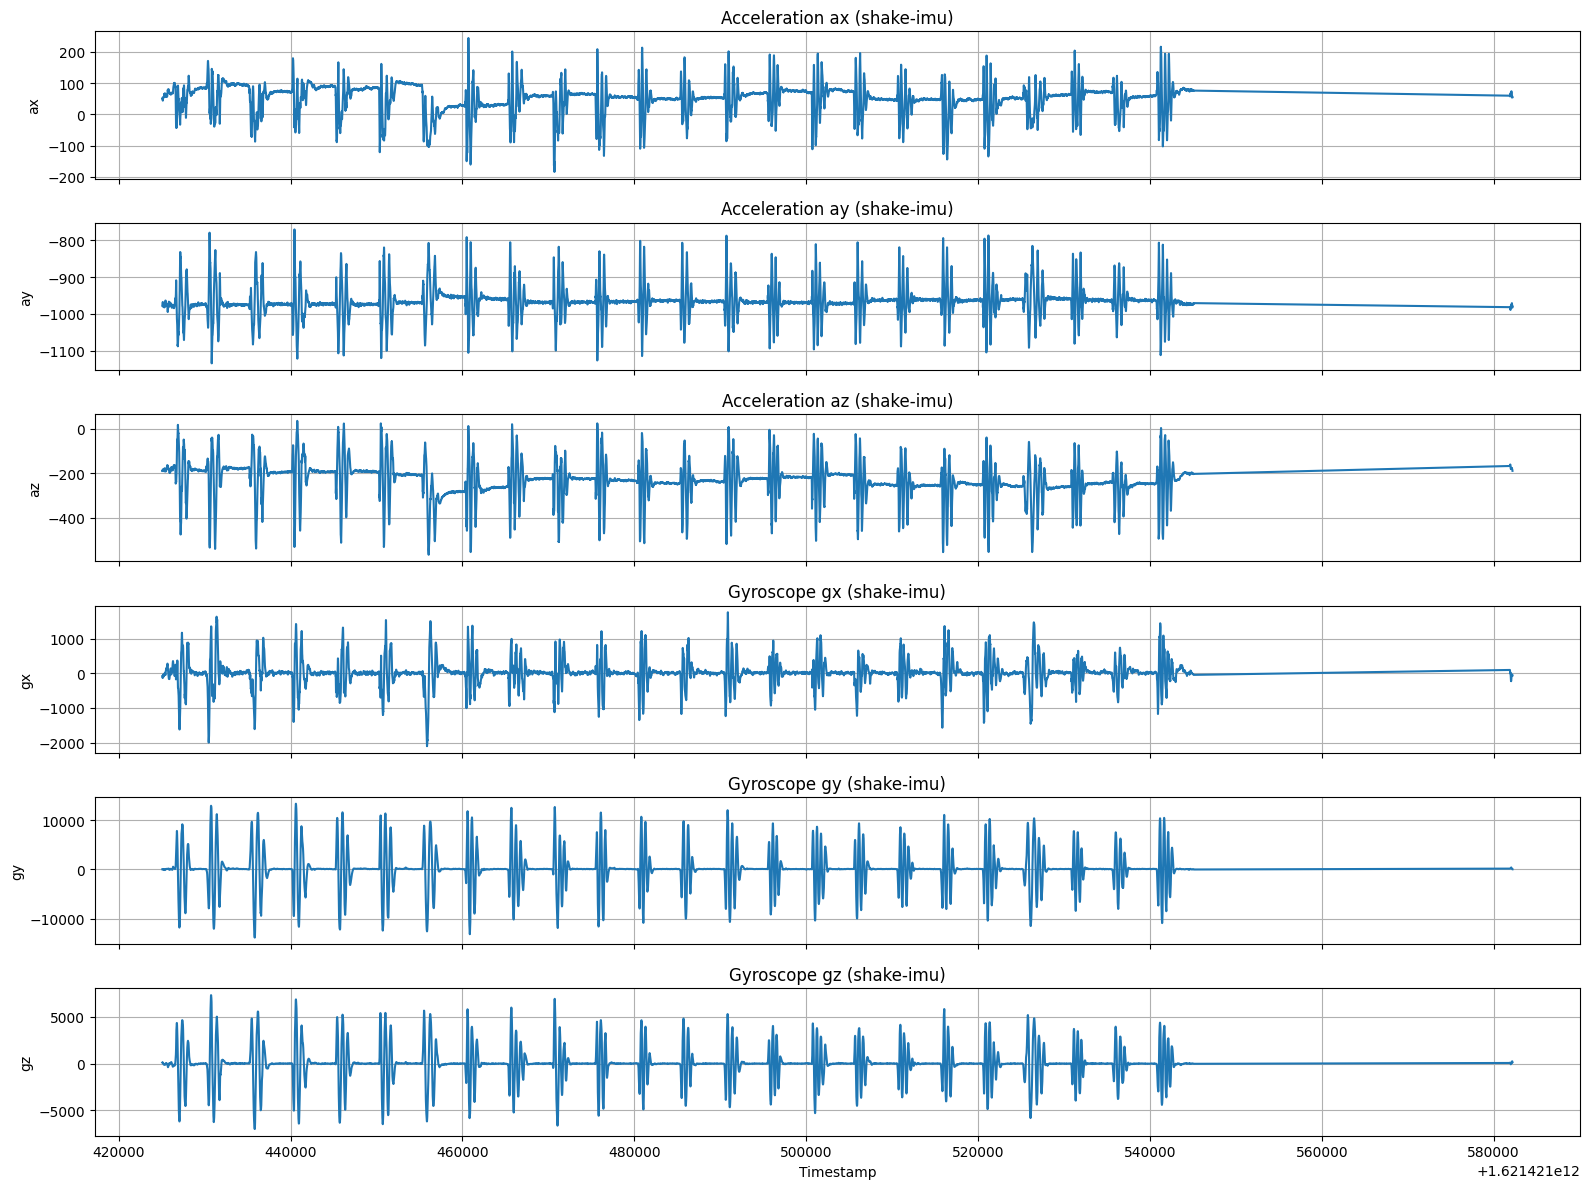

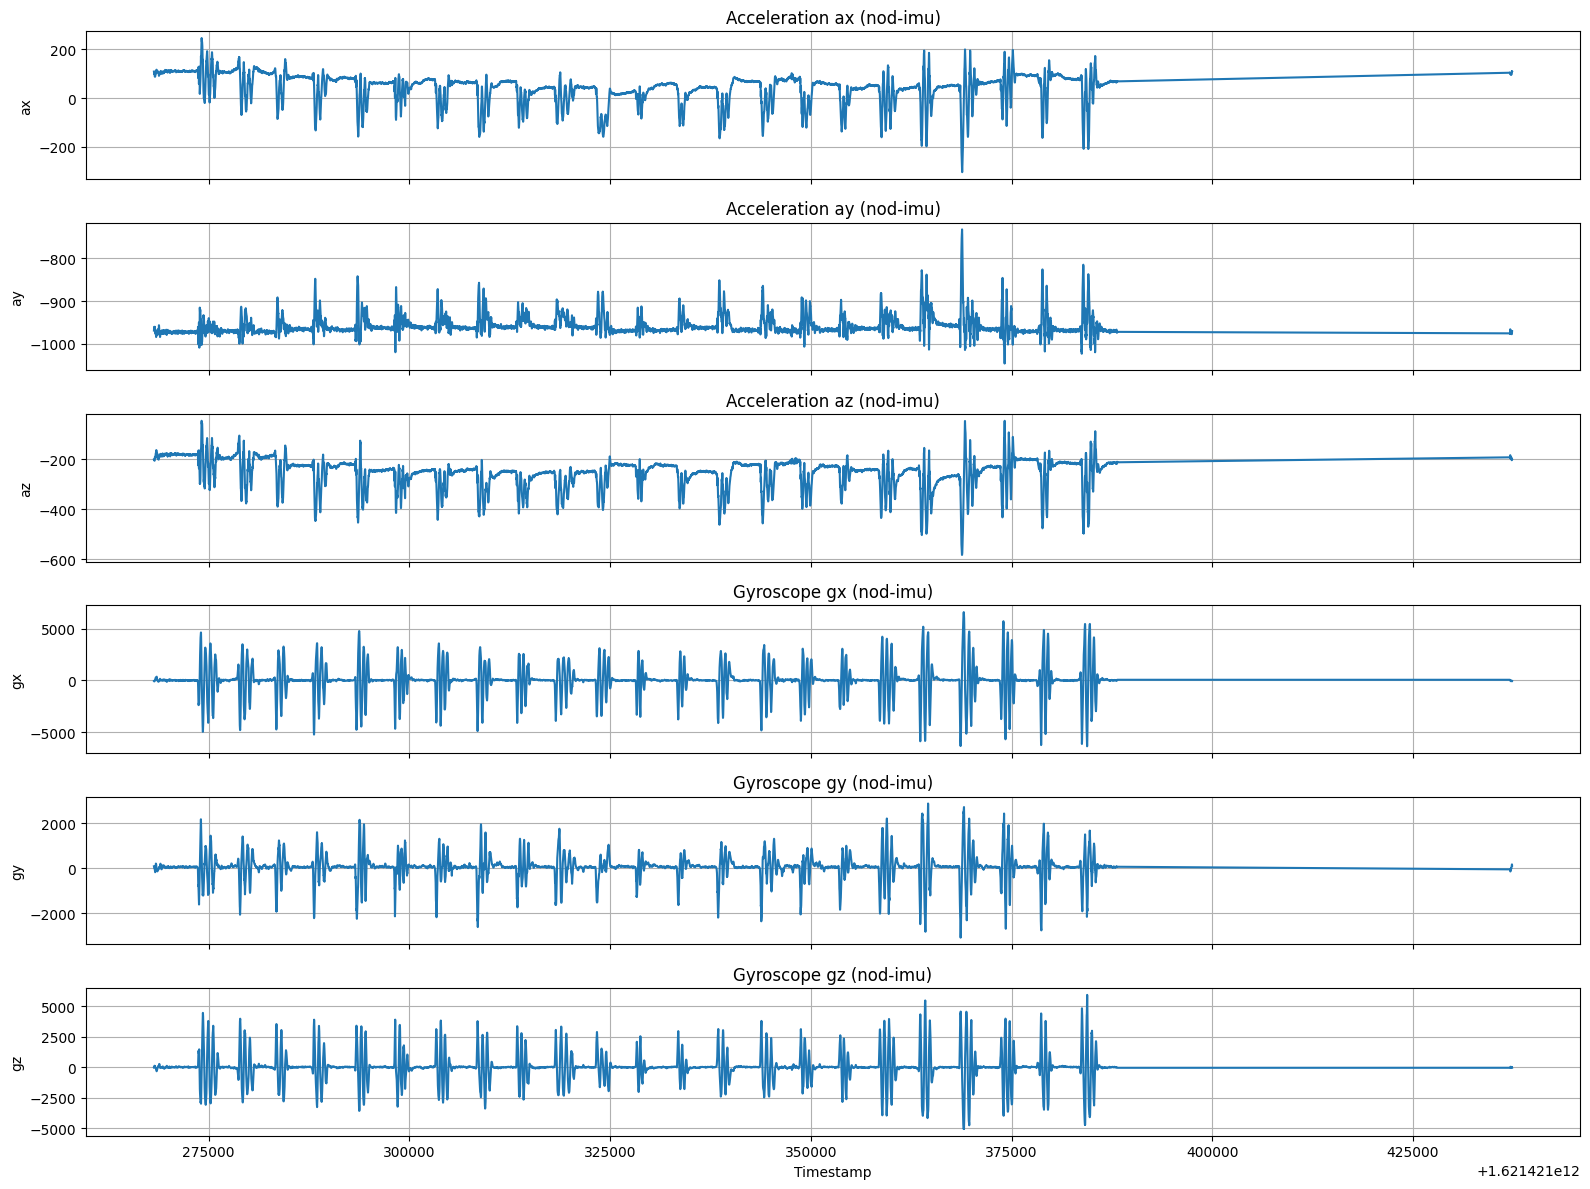

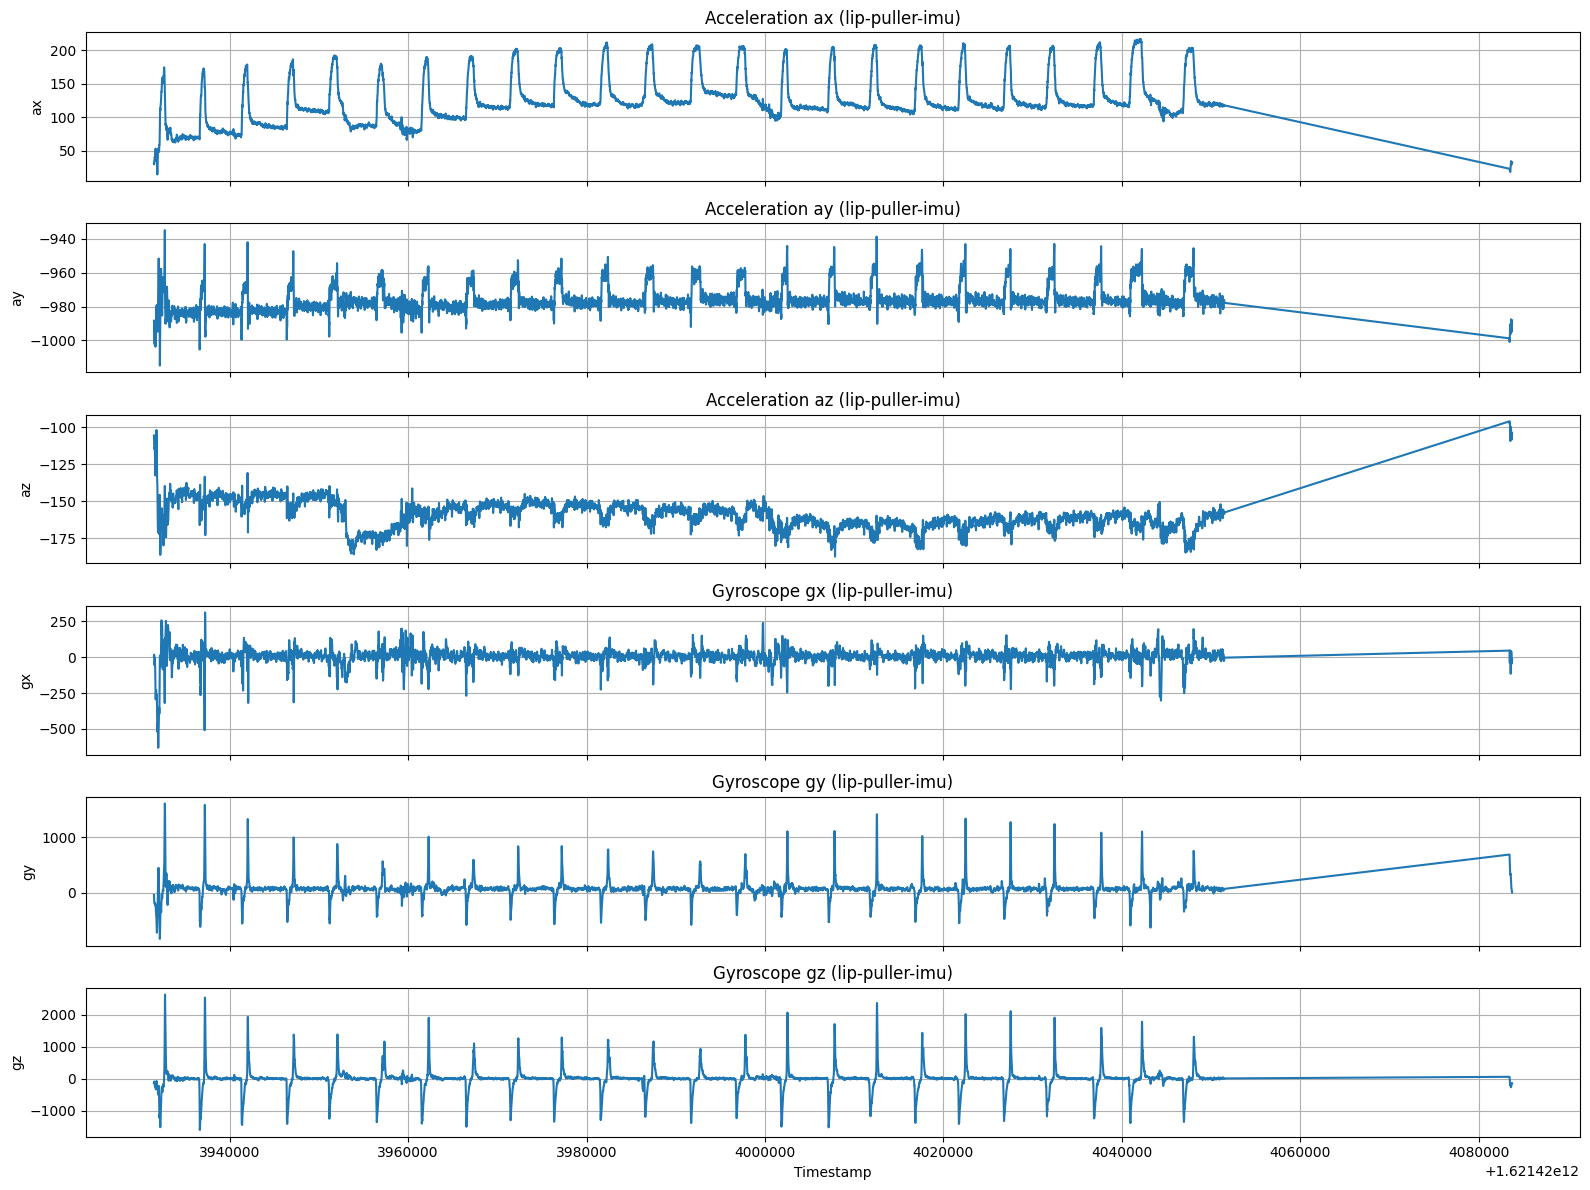

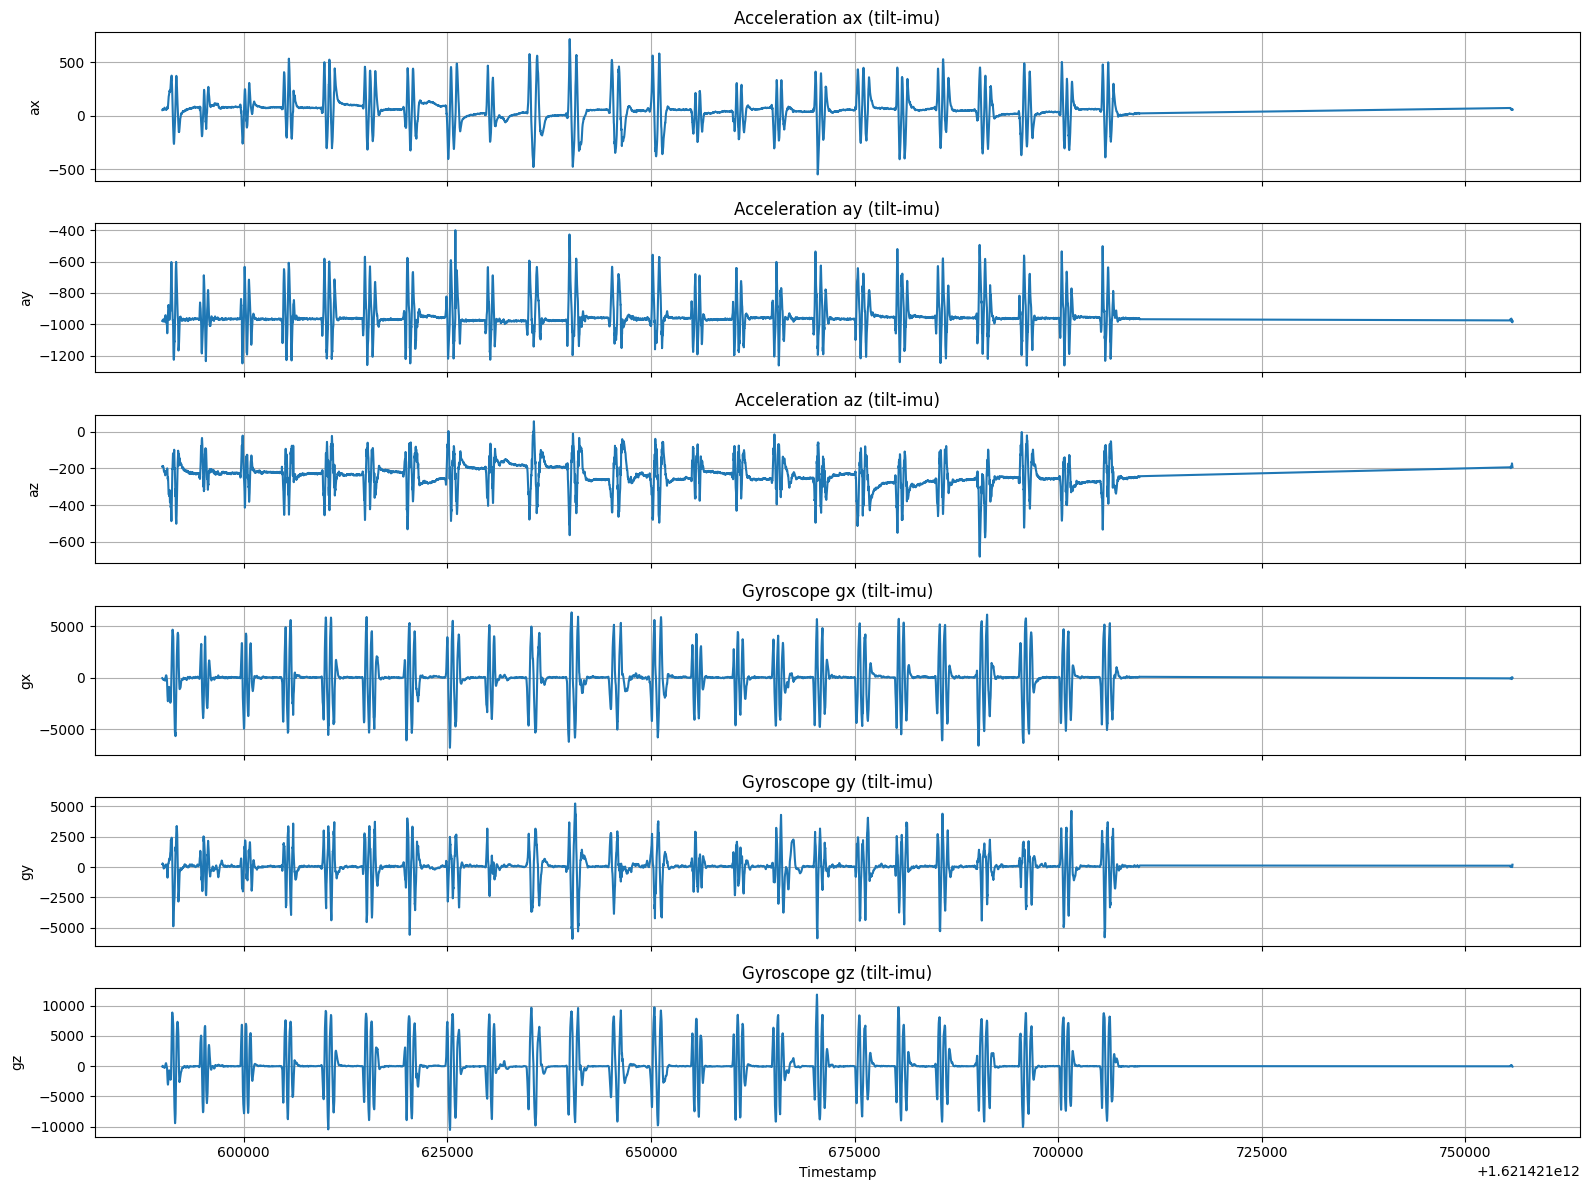

In [ ]:
# this frame is for plotting each imu gestures for each individual on the same plot
import matplotlib.pyplot as plt

def plot_all_imu_data(plot_list, participant_id, filename_to_plot):
  df = None
  for p_id, data_entries in plot_list.items():
    if p_id == participant_id:
      for d_frame, f_name in data_entries:
        if f_name == filename_to_plot:
          df = d_frame
          break
      if df is not None:
        break
  fig, axes = plt.subplots(6, 1, figsize=(16,12), sharex = True)

  accel_cols = ['ax', 'ay', 'az']
  gyro_cols = ['gx', 'gy', 'gz']
  all_cols = accel_cols + gyro_cols

  for i, col in enumerate(all_cols):
    axes[i].plot(df['timestamp'], df[col], label=col)
    axes[i].set_ylabel(col)
    axes[i].grid(True) # set it to false later to check what it does
    if col in accel_cols:
      axes[i].set_title(f'Acceleration {col} ({filename_to_plot})')
    else:
      axes[i].set_title(f'Gyroscope {col} ({filename_to_plot})')

  axes[-1].set_xlabel('Timestamp')
  plt.tight_layout()
  plt.show()



#call
plot_all_imu_data(section_dict, 1, "shake-imu")
plot_all_imu_data(section_dict, 1, "nod-imu")
plot_all_imu_data(section_dict, 1, "lip-puller-imu")
plot_all_imu_data(section_dict, 1, "tilt-imu")
# plot_all_imu_data(section_dict, 1, "mouth-stretch-imu")

## Old features calculation

In [ ]:
def mean_crossing_rate(data_series):
  mean_value = np.mean(data_series) # this line calculates the mean of all values in the data series
  crossings = np.where(np.diff(np.sign(data_series - mean_value)))[0]
  mcr = len(crossings) / len(data_series)
  return mcr

def extract_features_with_tag(df, filename):
  features = {}
  numeric_cols = df.select_dtypes(include=np.number).columns.drop('timestamp', errors='ignore')

  for col in numeric_cols:
    features[f'{col}_mean'] = df[col].mean()
    features[f'{col}_std'] = df[col].std()
    if (col == 'gy'):
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))
      features[f'{col}_mean_crossing_rate'] = mean_crossing_rate(df[col])

    if len(numeric_cols) >= 3:
      corr_matrix = df[numeric_cols].corr()

      #Extract specific correlations
      if 'ax' in numeric_cols and 'ay' in numeric_cols:
        features['ax_ay_corr'] = corr_matrix.loc['ax','ay']
      if 'ax' in numeric_cols and 'az' in numeric_cols:
        features['ax_az_corr'] = corr_matrix.loc['ax', 'az']
      if 'ay' in numeric_cols and 'az' in numeric_cols:
          features['ay_az_corr'] = corr_matrix.loc['ay', 'az']
      if 'gx' in numeric_cols and 'gy' in numeric_cols:
          features['gx_gy_corr'] = corr_matrix.loc['gx', 'gy']
      if 'gx' in numeric_cols and 'gz' in numeric_cols:
          features['gx_gz_corr'] = corr_matrix.loc['gx', 'gz']
      if 'gy' in numeric_cols and 'gz' in numeric_cols:
          features['gy_gz_corr'] = corr_matrix.loc['gy', 'gz']

  features['classification_tag'] = filename
  return features




In [ ]:
# this block shows how my features data frame will look like
all_features = []
for data_list in section_dict.values():
  for df, filename in data_list:
    features = extract_features_with_tag(df, filename)
    all_features.append(features)

features_df = pd.DataFrame(all_features)
display(features_df)


,ax_mean,ax_std,ax_ay_corr,ax_az_corr,ay_az_corr,gx_gy_corr,gx_gz_corr,gy_gz_corr,ay_mean,ay_std,...,az_std,gx_mean,gx_std,gy_mean,gy_std,gy_rms,gy_mean_crossing_rate,gz_mean,gz_std,classification_tag
0,52.690375,45.879881,-0.720480,0.731529,-0.945991,0.814959,0.802831,0.990454,-965.800222,39.318714,...,80.090419,13.378669,372.731197,60.920230,3536.709770,3537.093366,0.055520,1.077457,1720.303984,shake-imu
1,123.690232,33.557946,0.851000,-0.399541,-0.439649,-0.022010,0.050198,0.889727,-975.896834,7.163343,...,9.296010,4.492139,54.813722,70.694438,156.890187,172.076349,0.082994,3.109808,330.540843,lip-puller-imu
2,51.595141,140.304355,0.860644,-0.838156,-0.792907,-0.655732,0.972210,-0.579791,-950.744223,98.726126,...,74.399300,-48.176029,1818.320572,35.879748,1158.857715,1159.366809,0.042930,37.429780,3086.305874,tilt-imu
3,44.197888,60.841893,-0.798976,0.924857,-0.877795,0.863303,-0.975959,-0.880628,-957.792561,22.906096,...,59.667320,7.271625,1442.886062,55.201005,562.088055,564.769795,0.053304,-1.305298,1183.946621,nod-imu
4,-73.540379,39.214333,0.275436,0.506854,0.760849,-0.229765,-0.051327,-0.293759,-973.207394,6.478224,...,41.479408,30.586452,123.185140,34.121998,90.517270,96.731759,0.089524,8.833400,204.973278,lip-puller-imu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,-332.586616,27.227823,0.399519,-0.097188,0.794259,0.944053,0.573544,0.564305,886.080041,21.039082,...,51.560968,122.815060,1133.875136,-5.199283,748.865079,748.853293,0.079203,-19.632032,195.296243,nod-imu
92,-250.773780,129.276097,0.616521,-0.978591,-0.736163,0.112257,-0.179329,0.300787,-2.708372,102.130959,...,38.544819,63.433304,82.764152,99.200128,131.633390,164.823031,0.115590,2.408079,97.040504,lip-puller-imu
93,-337.425383,108.319240,0.321498,-0.627173,0.224037,-0.857167,0.953254,-0.840231,48.386318,153.361921,...,56.588079,42.947910,2132.348066,137.864391,1353.023887,1359.975807,0.048341,20.657147,3606.372527,shake-imu
94,-279.132063,127.621077,-0.699872,-0.282417,-0.124791,0.908803,-0.908825,-0.887673,86.275057,224.081295,...,33.713060,64.698285,1943.190563,77.279378,1074.276007,1077.009272,0.066454,21.703470,836.597112,nod-imu


In [ ]:
import matplotlib.pyplot as plt

def plot_acceleration_data(plot_list, filename_to_plot):
    """
    Plots the acceleration data from a dataframe.

    Args:
        df: pandas DataFrame
        filename_to_plot: string representing the filename to plot
    """
    plt.figure(figsize=(16, 6))
    for df, filename in plot_list:
        if filename == filename_to_plot:
            # plt.plot(df['timestamp'], df['gx'], label='gx')
            # plt.plot(df['timestamp'], df['gy'], label='gy')
            # plt.plot(df['timestamp'], df['gz'], label='gz')
            # plt.plot(df['timestamp'], df['ay'], label='ay')
            plt.plot(df['timestamp'], df['az'], label='az')
            plt.title(f'Acceleration data for {filename}')
            plt.xlabel('Timestamp')
            plt.ylabel('Acceleration')
            plt.legend()
            plt.grid(True)
            plt.show()
            break
# plot_acceleration_data(part_dict[17], "tilt-imu")


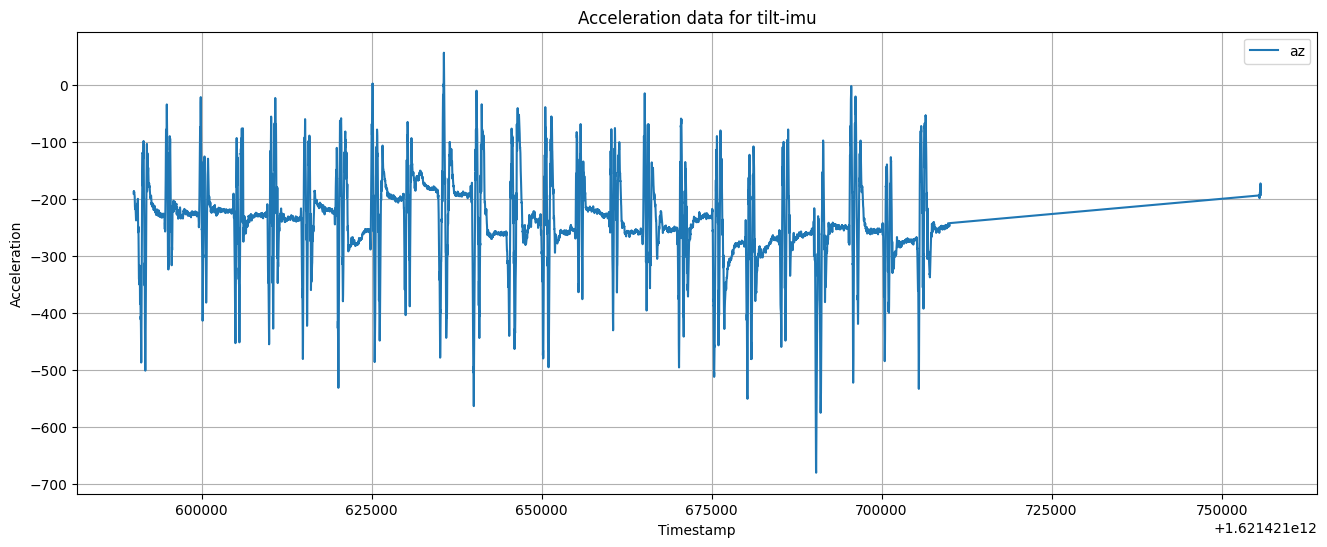

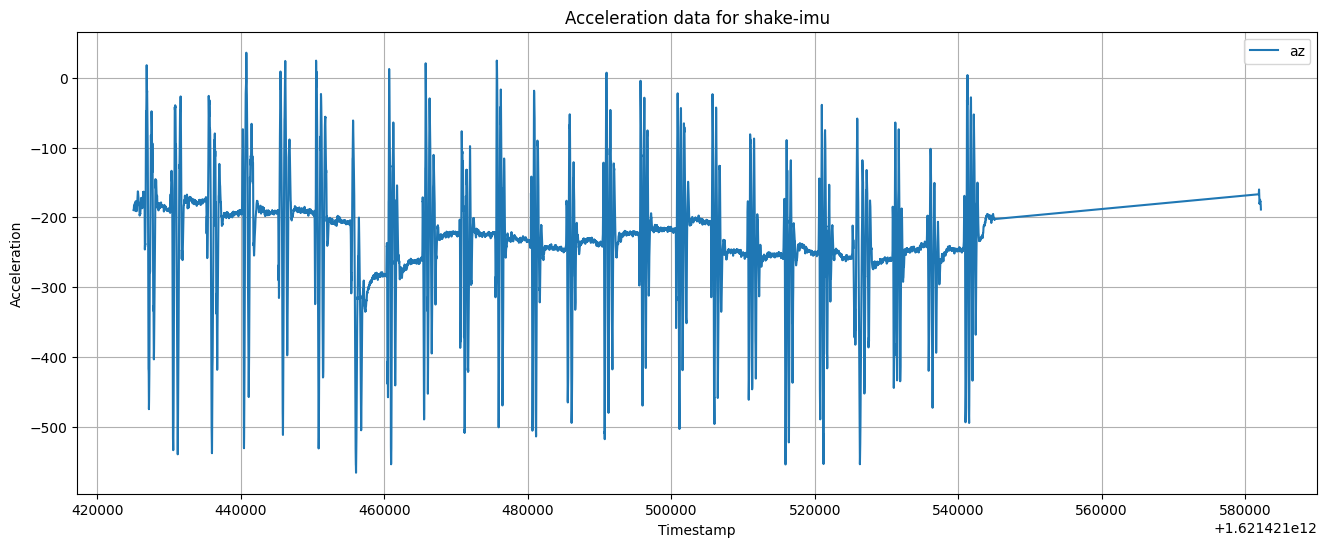

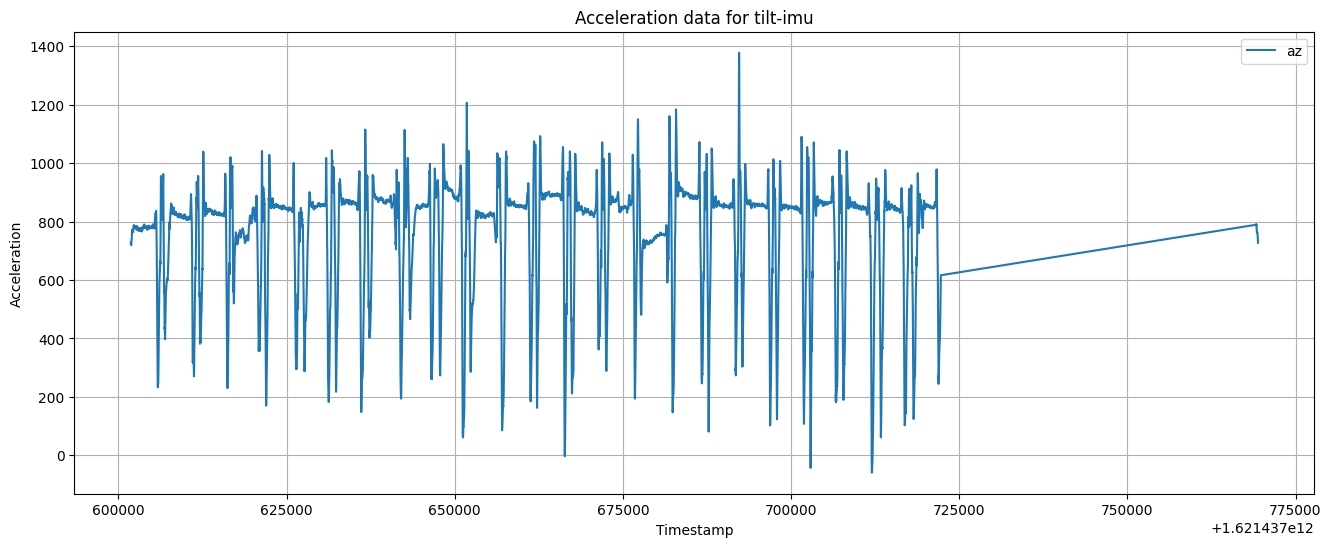

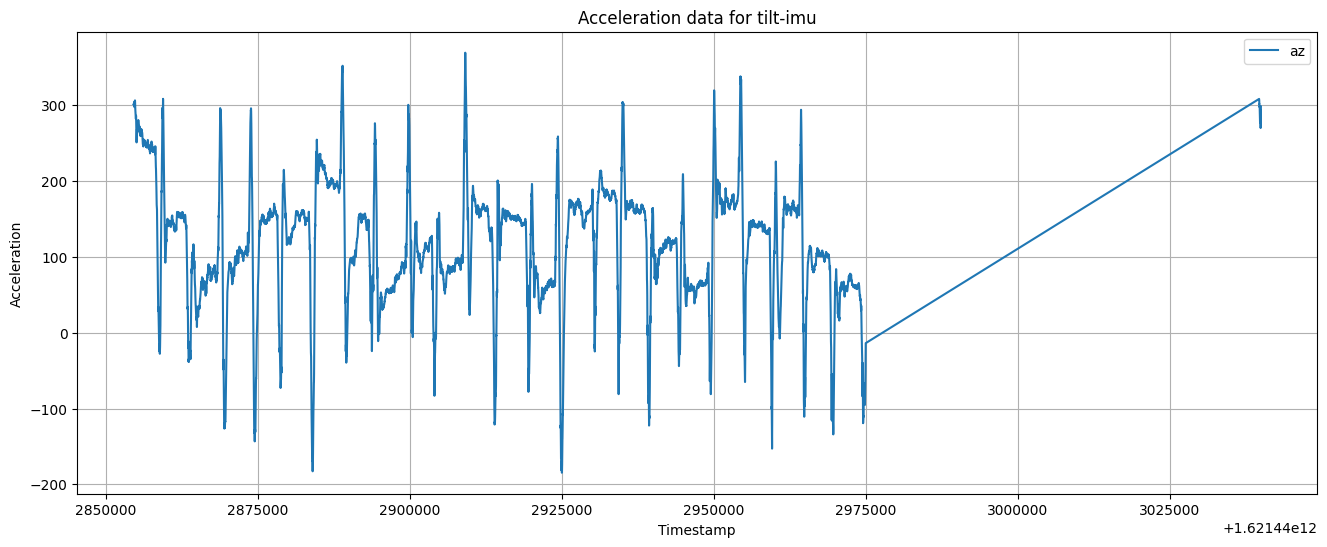

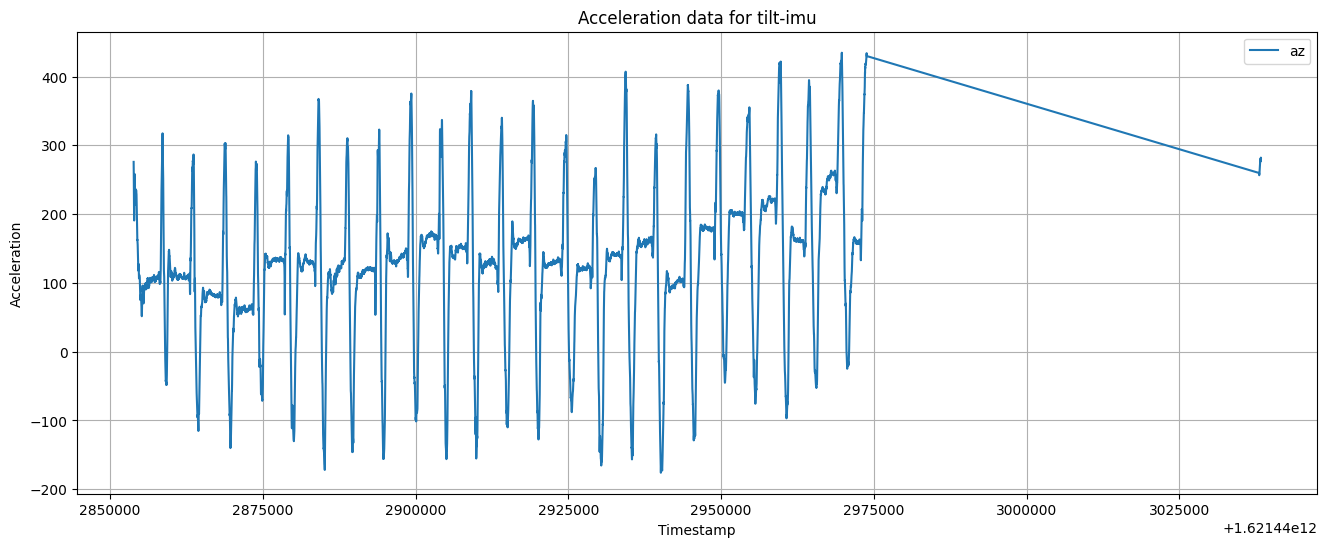

In [ ]:
plot_acceleration_data(part_dict[1], "tilt-imu")
plot_acceleration_data(part_dict[1], "shake-imu")
plot_acceleration_data(part_dict[5], "tilt-imu")
plot_acceleration_data(part_dict[6], "tilt-imu")
plot_acceleration_data(part_dict[7], "tilt-imu")

# Task
Convert the time domain data in the dataframes within the lists `p1`, `p2`, `p3`, `p4`, and `p5` to the frequency domain using Fast Fourier Transform (FFT).

## Define fft function

### Subtask:
Create a function to perform the FFT on a given column of a dataframe. This function should handle potential issues like non-uniform timestamps if necessary.


**Reasoning**:
Define the `perform_fft` function to calculate the FFT of a time series and its corresponding frequencies.



In [ ]:
import numpy as np

def perform_fft(data_series, timestamp_series):
  time_diffs = np.diff(timestamp_series)
  sampling_rate = 1000 # we have assumed sampling rate over here, should we use the median technique to calculate it?
  fft_results = np.fft.fft(data_series)
  frequencies = np.fft.fftfreq(len(data_series), d=1.0/sampling_rate)
  return np.abs(fft_results), frequencies

# this functions returns the frequencies (X-axis) and their magnitudes (Y-axis)

## Apply fft to all dataframes

### Subtask:
Iterate through the `p1`, `p2`, `p3`, `p4`, and `p5` lists and apply the FFT function to each relevant column (excluding 'timestamp') in each dataframe.


**Reasoning**:
Initialize dictionaries to store the frequency domain data for each participant list and iterate through the lists and dataframes to apply the FFT function to relevant columns.



In [ ]:
fft_results_dict = {}

for part_idx, data_list in section_dict.items():
  fft_results_dict[part_idx] = {}
  for df, filename in data_list:
    file_key = f'{filename}'
    fft_results_dict[part_idx][file_key] = {}
    for col in df.select_dtypes(include=np.number).columns:
      if col == 'timestamp':
        continue
      magnitudes, frequencies = perform_fft(df[col], df['timestamp'])
      fft_results_dict[part_idx][file_key][col] = {
          'magnitudes': magnitudes,
          'frequencies': frequencies
      }

print(fft_results_dict)

# this portion of code performs fft on each df and then stores the result of in fft_results_dict

{1: {'shake-imu': {'ax': {'magnitudes': array([660526.544     ,  39523.02307987,  86530.35597118, ...,
        15341.42618137,  86530.35597118,  39523.02307987]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'ay': {'magnitudes': array([1.21072716e+07, 1.75916696e+04, 3.70981295e+04, ...,
       1.15312334e+04, 3.70981295e+04, 1.75916696e+04]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'az': {'magnitudes': array([2908279.676     ,   98587.9592939 ,  169465.96001917, ...,
         41661.06870528,  169465.96001917,   98587.9592939 ]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'gx': {'magnitudes': array([167715.        ,  39750.09409937,  51324.70328649, ...,
        34052.45709508,  51324.70328649,  39750.09409937]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052,

## Store frequency domain data

### Subtask:
Decide how to store the resulting frequency domain data. This could be in new dataframes, or by adding new columns to the existing dataframes.


**Reasoning**:
Based on the existing `features_df` which contains time-domain features for each file, and the need for subsequent analysis or machine learning, it makes sense to augment this DataFrame with aggregated frequency-domain features rather than creating entirely new DataFrames. This keeps all features for a single file in one place. I will extract relevant features from the FFT results and add them as new columns to `features_df`.



In [ ]:
# we had already stored the ffts magnitudes and resulting frequencies and now we are trying to get the features from it

fft_features = []

for part_idx, data_list in section_dict.items():
  for df, filename in data_list:
    file_key = f'{filename}'
    features = {'classification_tag': filename}
    fft_data = fft_results_dict[part_idx][file_key]

    for col, fft_result in fft_data.items():
      magnitudes = fft_result['magnitudes']
      frequencies = fft_result['frequencies']

      if(len(magnitudes[1:]) > 0):
        dominant_frequency_index = np.argmax(magnitudes[1:]) + 1
        dominant_frequency = frequencies[dominant_frequency_index]
        features[f'{col}_dominant_frequency'] = dominant_frequency
      else:
        features[f'{col}_dominant_frequency'] = np.nan

      features[f'{col}_total_energy'] = np.sum(magnitudes**2)

      low_freq_band_indices = np.where((frequencies >= 0) & (frequencies <= 10))
      features[f'{col}_low_freq_energy'] = np.sum(magnitudes[low_freq_band_indices]**2)

    fft_features.append(features)

fft_features_df = pd.DataFrame(fft_features)
features_df = fft_features_df

# display(fft_features_df.head())

display(features_df.head())


#             # Extract energy in specific frequency bands (example: low frequency energy)
#             # Define frequency bands (example: 0-10 Hz)
#             low_freq_band_indices = np.where((frequencies >= 0) & (frequencies <= 10))
#             features[f'{col}_low_freq_energy'] = np.sum(magnitudes[low_freq_band_indices]**2)


#         fft_features.append(features)

# fft_features_df = pd.DataFrame(fft_features)

# # Merge the new FFT features with the existing features_df
# # features_df = pd.merge(features_df, fft_features_df, on='classification_tag', how='left')

# display(features_df.head())

,classification_tag,ax_dominant_frequency,ax_total_energy,ax_low_freq_energy,ay_dominant_frequency,ay_total_energy,ay_low_freq_energy,az_dominant_frequency,az_total_energy,az_low_freq_energy,gx_dominant_frequency,gx_total_energy,gx_low_freq_energy,gy_dominant_frequency,gy_total_energy,gy_low_freq_energy,gz_dominant_frequency,gz_total_energy,gz_low_freq_energy
0,shake-imu,1.914486,7.670667e+11,4.950267e+11,17.070836,1.468290e+14,1.465932e+14,0.159541,9.466053e+12,8.548873e+12,18.347160,2.185919e+13,1.929783e+12,17.070836,1.966124e+15,4.114990e+13,-17.070836,4.650438e+14,9.709117e+12
1,lip-puller-imu,-1.915250,2.579202e+12,2.488361e+12,1.915250,1.495556e+14,1.495506e+14,0.079802,4.001324e+12,3.993808e+12,-1.915250,4.749225e+11,7.649819e+10,3.830500,4.649581e+12,1.707878e+12,3.830500,1.715637e+13,5.318214e+12
2,tilt-imu,13.246090,3.509431e+12,8.286895e+11,17.315672,1.434913e+14,1.420523e+14,-0.079796,9.870231e+12,9.168682e+12,15.400575,5.195793e+14,2.507821e+13,-14.602617,2.110972e+14,1.406201e+13,15.400575,1.496056e+15,6.888350e+13
3,mouth-stretch-imu,-0.079802,1.392493e+11,1.242972e+11,1.915250,1.515770e+14,1.515748e+14,-0.079802,4.470112e+12,4.432804e+12,-1.915250,2.572521e+12,8.280889e+11,3.750698,1.669967e+12,9.097291e+11,3.830500,7.808543e+11,1.637794e+11
4,nod-imu,-1.915097,8.881069e+11,4.879736e+11,1.915097,1.441558e+14,1.440905e+14,-1.915097,1.053376e+13,1.013942e+13,15.240983,3.269499e+14,8.671612e+12,17.235876,5.009377e+13,4.317147e+12,15.240983,2.201258e+14,5.167607e+12


# Calculating merged features here

In [ ]:
def calculate_merged_features(df, filename):
  features = {}
  numeric_cols = df.select_dtypes(include=np.number).columns.drop('timestamp', errors='ignore')

  for col in numeric_cols:
    if (col == 'gy'):
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))

  if len(numeric_cols) >= 3:
    corr_matrix = df[numeric_cols].corr()

    #Extract specific correlations
    if 'ax' in numeric_cols and 'ay' in numeric_cols:
      features['ax_ay_corr'] = corr_matrix.loc['ax','ay']
    if 'ax' in numeric_cols and 'az' in numeric_cols:
      features['ax_az_corr'] = corr_matrix.loc['ax', 'az']
    if 'ay' in numeric_cols and 'az' in numeric_cols:
        features['ay_az_corr'] = corr_matrix.loc['ay', 'az']
    if 'gx' in numeric_cols and 'gy' in numeric_cols:
        features['gx_gy_corr'] = corr_matrix.loc['gx', 'gy']
    if 'gx' in numeric_cols and 'gz' in numeric_cols:
        features['gx_gz_corr'] = corr_matrix.loc['gx', 'gz']
    if 'gy' in numeric_cols and 'gz' in numeric_cols:
        features['gy_gz_corr'] = corr_matrix.loc['gy', 'gz']

  time_diffs = np.diff(df['timestamp'])
  median_diff_sec = np.median(time_diffs) / 1000
  sampling_rate = 1/ median_diff_sec if median_diff_sec > 0 else 50

  for col in numeric_cols:
    fft_vals = np.fft.fft(df[col].values)
    freqs = np.fft.fftfreq(len(df[col]), d= median_diff_sec)

    magnitude = np.abs(fft_vals)
    pos_mask = freqs > 0
    freqs = freqs[pos_mask]
    magnitude = magnitude[pos_mask]

    if len(magnitude) > 0 :
      dom_freq_idx = np.argmax(magnitude)
      features[f'{col}_dom_freq'] = freqs[dom_freq_idx]
      features[f'{col}_energy'] = np.sum(magnitude**2)
    else: # Ensure features are always present, even if magnitude is empty
      features[f'{col}_dom_freq'] = 0.0 # Use 0.0 or np.nan as a placeholder
      features[f'{col}_energy'] = 0.0 # Use 0.0 or np.nan as a placeholder

  features['classification_tag'] = filename
  return features

all_features_rows = []
for person_id, files in section_dict.items():
  for df, gesture_name in files:
    row_features = calculate_merged_features(df, gesture_name)
    row_features['person_id'] = person_id
    all_features_rows.append(row_features)

merged_df = pd.DataFrame(all_features_rows)
display(merged_df.head())

,gy_rms,ax_ay_corr,ax_az_corr,ay_az_corr,gx_gy_corr,gx_gz_corr,gy_gz_corr,ax_dom_freq,ax_energy,ay_dom_freq,...,az_dom_freq,az_energy,gx_dom_freq,gx_energy,gy_dom_freq,gy_energy,gz_dom_freq,gz_energy,classification_tag,person_id
0,3537.093366,-0.720480,0.731529,-0.945991,0.814959,0.802831,0.990454,0.191449,1.653857e+11,1.707084,...,0.015954,5.039813e+11,1.834716,1.091553e+13,1.707084,9.827706e+14,1.707084,2.325218e+14,shake-imu,1
1,172.076349,0.851000,-0.399541,-0.439649,-0.022010,0.050198,0.889727,0.191525,8.840922e+10,0.191525,...,0.007980,6.784221e+09,0.191525,2.358769e+11,0.383050,1.932406e+12,0.383050,8.577428e+12,lip-puller-imu,1
2,1159.366809,0.860644,-0.838156,-0.792907,-0.655732,0.972210,-0.579791,1.324609,1.545676e+12,1.731567,...,0.007980,4.346241e+11,1.540057,2.596074e+14,1.460262,1.054475e+14,1.540057,7.479181e+14,tilt-imu,1
3,564.769795,-0.798976,0.924857,-0.877795,0.863303,-0.975959,-0.880628,0.191510,2.906575e+11,0.191510,...,0.191510,2.795433e+11,1.524098,1.634708e+14,1.723588,2.480760e+13,1.524098,1.100628e+14,nod-imu,1
4,96.731759,0.275436,0.506854,0.760849,-0.229765,-0.051327,-0.293759,0.015958,1.207633e+11,0.007979,...,0.007979,1.351172e+11,0.191494,1.191687e+12,0.327136,6.434404e+11,0.279263,3.299438e+12,lip-puller-imu,3


Overall Accuracy: 0.9130434782608695
Overall Classification Report:
                precision    recall  f1-score   support

lip-puller-imu       0.85      1.00      0.92        23
       nod-imu       0.88      0.91      0.89        23
     shake-imu       1.00      0.78      0.88        23
      tilt-imu       0.96      0.96      0.96        23

      accuracy                           0.91        92
     macro avg       0.92      0.91      0.91        92
  weighted avg       0.92      0.91      0.91        92



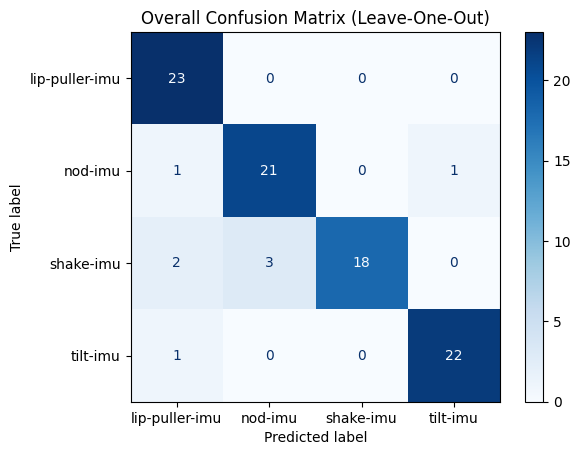

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt


X = merged_df.drop('classification_tag', axis=1)
y = merged_df['classification_tag']

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
svm_model = SVC(kernel='linear')

for train_index, test_index in loo.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test  = scaler.transform(X_test)

  svm_model.fit(X_train, y_train)

  y_pred = svm_model.predict(X_test)

  y_true_all.extend(y_test)
  y_pred_all.extend(y_pred)

accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"Overall Accuracy: {accuracy}")
print("Overall Classification Report:")
print(classification_report(y_true_all, y_pred_all))

overall_cm = confusion_matrix(y_true_all, y_pred_all)
disp_overall = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=svm_model.classes_)
disp_overall.plot(cmap=plt.cm.Blues)
plt.title('Overall Confusion Matrix (Leave-One-Out)')
plt.show()


In [ ]:
expected_feature_columns = X.columns # Get the feature names and order from the training data X

# Instantiate the StandardScaler once, outside the loop, and fit it on the entire training data (X).
# For this demonstration, we'll refit it on `X` in this cell, as it wasn't explicitly saved from `qaaB1kwf3cib`.
# In a production setting, `final_scaler` should be saved after training.
final_scaler_for_prediction = StandardScaler()
final_scaler_for_prediction.fit(X) # Fit on the entire training dataset
y_test_true_all = []
y_test_pred_all = []

for i in range(25, 30):
  for gesture in gestures:
    test_frame = pd.read_csv(f"/content/drive/MyDrive/Wireless project/P{i}/{i}-{gesture}-left.csv")
    test_frame = test_frame.pipe(scale_columns) # Apply scaling as done for training data
    time_feature = calculate_merged_features(test_frame, gesture)

    time_feature_df = pd.DataFrame(time_feature, index=[0])
    y_actual = time_feature_df['classification_tag']

    X_test_temp = time_feature_df.drop('classification_tag', axis=1)

    # Reindex X_test to match the training feature order and ensure all columns are present
    # Fill missing columns (if any, though should be none after fix in calculate_merged_features) with 0
    X_test = X_test_temp.reindex(columns=expected_feature_columns, fill_value=0)

    # Transform X_test using the scaler fitted on the training data
    X_test = final_scaler_for_prediction.transform(X_test)

    y_pred = svm_model.predict(X_test)
    y_test_true_all.extend(y_actual)
    y_test_pred_all.extend(y_pred)
    # print(y_pred, y_actual)
print("============================================")
accuracy = accuracy_score(y_test_true_all, y_test_pred_all)
print(f"Unseen Accuracy: {accuracy}")


Unseen Accuracy: 0.85
